# Heart Attack Prediction Model 
This model is based on quantitative and qualitative data of the diffrent patients, from common measured health parameters like Blood Preasure, Cholerterol levels, Heart rate etc, to lifestyle choices such as Excercise rate, Alcohol consumption and so on.  

In [1]:
import numpy as nu
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, f1_score, recall_score

In [2]:
import os

folder = os.getcwd()

In [3]:
print(folder)

c:\Users\USER\Desktop\Codes\Git_\AI\Predictive_Heart_Attack_Model


In [4]:
Heart_Data =pd.read_csv ( f"{folder}/heart_attack_russia.csv" )
print(Heart_Data.info())
print(Heart_Data.head())
print(Heart_Data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Region                 50000 non-null  object 
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  object 
 9   Smoking                50000 non-null  bool   
 10  Alcohol_Consumption    24976 non-null  object 
 11  Diabetes               50000 non-null  bool   
 12  Family_History         50000 non-null  bool   
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  bool   
 15  An

In [5]:
# Clean Data by filling in missing values with 0
Heart_Data = Heart_Data.fillna("None")

print(Heart_Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Region                 50000 non-null  object 
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  object 
 9   Smoking                50000 non-null  bool   
 10  Alcohol_Consumption    50000 non-null  object 
 11  Diabetes               50000 non-null  bool   
 12  Family_History         50000 non-null  bool   
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  bool   
 15  An

## Exploratort Data Analysis 

In [6]:
Heart_Data.head()

,ID,Age,Gender,Region,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Exercise_Level,Smoking,...,Income_Level,Physical_Activity,Education_Level,Marital_Status,Urban_Rural,Medication,Health_Awareness,Daily_Water_Intake,Mental_Health,Obesity
0,1,50,Male,Rural,110.0,196.5,15.9,76,High,False,...,Low,Low,Primary,Married,Rural,False,5,2.3,5,False
1,2,40,Female,Urban,138.8,157.5,27.1,82,Moderate,False,...,Low,Moderate,Higher,Married,Urban,False,1,5.0,4,False
2,3,26,Male,Rural,116.0,210.1,27.2,71,Moderate,False,...,Middle,High,Primary,Married,Urban,False,4,2.4,8,False
3,4,54,Female,Rural,133.5,170.5,26.0,74,Moderate,True,...,Middle,Moderate,Higher,Married,Urban,False,2,2.7,6,True
4,5,19,Female,Urban,108.0,224.5,27.5,67,Low,False,...,Middle,Low,Higher,Widowed,Urban,False,4,3.5,4,True


In [7]:
Heart_Data.describe()

,ID,Age,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Stress_Level,Sleep_Hours,Health_Awareness,Daily_Water_Intake,Mental_Health
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,25000.500000,35.991820,120.058636,199.852762,24.983912,79.988980,5.503700,7.011464,3.007100,2.997782,5.48674
std,14433.901067,14.110139,14.975835,49.998331,5.003784,11.804567,2.870741,1.740651,1.410351,1.149608,2.86076
min,1.000000,12.000000,60.000000,-18.700000,2.900000,60.000000,1.000000,4.000000,1.000000,1.000000,1.00000
25%,12500.750000,24.000000,109.900000,166.100000,21.600000,70.000000,3.000000,5.500000,2.000000,2.000000,3.00000
50%,25000.500000,36.000000,120.050000,199.900000,25.000000,80.000000,6.000000,7.000000,3.000000,3.000000,5.00000
75%,37500.250000,48.000000,130.200000,233.500000,28.400000,90.000000,8.000000,8.500000,4.000000,4.000000,8.00000
max,50000.000000,60.000000,188.400000,398.800000,46.100000,100.000000,10.000000,10.000000,5.000000,5.000000,10.00000


In [8]:
print("Integer and Float Columns:", Heart_Data.select_dtypes(include=['int64', 'float64']).columns)
print("Boolean Columns:", Heart_Data.select_dtypes(include=['bool']).columns)
print("String Columns:", Heart_Data.select_dtypes(include=['object']).columns)

Integer and Float Columns: Index(['ID', 'Age', 'Blood_Pressure', 'Cholesterol', 'BMI', 'Heart_Rate',
       'Stress_Level', 'Sleep_Hours', 'Health_Awareness', 'Daily_Water_Intake',
       'Mental_Health'],
      dtype='object')
Boolean Columns: Index(['Smoking', 'Diabetes', 'Family_History', 'Heart_Attack', 'Angina',
       'Heart_Disease_History', 'Medication', 'Obesity'],
      dtype='object')
String Columns: Index(['Gender', 'Region', 'Exercise_Level', 'Alcohol_Consumption', 'Diet',
       'Occupation', 'Income_Level', 'Physical_Activity', 'Education_Level',
       'Marital_Status', 'Urban_Rural'],
      dtype='object')


In [9]:
integer_columns = Heart_Data[['ID', 'Age', 'Blood_Pressure', 'Cholesterol', 'BMI', 'Heart_Rate',
       'Stress_Level', 'Sleep_Hours', 'Health_Awareness', 'Daily_Water_Intake',
       'Mental_Health']]

integer_columns = pd.DataFrame(integer_columns)
integer_columns.head()

,ID,Age,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Stress_Level,Sleep_Hours,Health_Awareness,Daily_Water_Intake,Mental_Health
0,1,50,110.0,196.5,15.9,76,8,9.4,5,2.3,5
1,2,40,138.8,157.5,27.1,82,5,5.5,1,5.0,4
2,3,26,116.0,210.1,27.2,71,8,8.8,4,2.4,8
3,4,54,133.5,170.5,26.0,74,5,8.2,2,2.7,6
4,5,19,108.0,224.5,27.5,67,1,5.9,4,3.5,4


In [10]:
boolean_columns = Heart_Data[['Smoking', 'Diabetes', 'Family_History', 'Heart_Attack', 'Angina',
       'Heart_Disease_History', 'Medication', 'Obesity']]

boolean_columns.head()
boolean_columns = pd.DataFrame(boolean_columns)
boolean_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Smoking                50000 non-null  bool 
 1   Diabetes               50000 non-null  bool 
 2   Family_History         50000 non-null  bool 
 3   Heart_Attack           50000 non-null  bool 
 4   Angina                 50000 non-null  bool 
 5   Heart_Disease_History  50000 non-null  bool 
 6   Medication             50000 non-null  bool 
 7   Obesity                50000 non-null  bool 
dtypes: bool(8)
memory usage: 390.8 KB


In [11]:
string_columns = Heart_Data[['Gender', 'Region', 'Exercise_Level', 'Alcohol_Consumption', 'Diet',
       'Occupation', 'Income_Level', 'Physical_Activity', 'Education_Level',
       'Marital_Status', 'Urban_Rural']]

string_columns = pd.DataFrame(string_columns)
string_columns.head()

,Gender,Region,Exercise_Level,Alcohol_Consumption,Diet,Occupation,Income_Level,Physical_Activity,Education_Level,Marital_Status,Urban_Rural
0,Male,Rural,High,Moderate,Unhealthy,Unemployed,Low,Low,Primary,Married,Rural
1,Female,Urban,Moderate,None,Unhealthy,Employed,Low,Moderate,Higher,Married,Urban
2,Male,Rural,Moderate,Moderate,Unhealthy,Employed,Middle,High,Primary,Married,Urban
3,Female,Rural,Moderate,Moderate,Healthy,Student,Middle,Moderate,Higher,Married,Urban
4,Female,Urban,Low,None,Unhealthy,Employed,Middle,Low,Higher,Widowed,Urban


In [12]:
for column in string_columns:
    Encode = LabelEncoder()
    Heart_Data[column] = Encode.fit_transform(Heart_Data[column])
    print(f"{column} unique values after encoding:", Heart_Data[column].unique())

Gender unique values after encoding: [1 0 2]
Region unique values after encoding: [0 2 1]
Exercise_Level unique values after encoding: [0 2 1]
Alcohol_Consumption unique values after encoding: [1 2 0]
Diet unique values after encoding: [2 0 1]
Occupation unique values after encoding: [3 0 2 1]
Income_Level unique values after encoding: [1 2 0]
Physical_Activity unique values after encoding: [1 2 0]
Education_Level unique values after encoding: [1 0 2]
Marital_Status unique values after encoding: [1 3 2 0]
Urban_Rural unique values after encoding: [0 1]


In [13]:
Heart_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  int64  
 3   Region                 50000 non-null  int64  
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  int64  
 9   Smoking                50000 non-null  bool   
 10  Alcohol_Consumption    50000 non-null  int64  
 11  Diabetes               50000 non-null  bool   
 12  Family_History         50000 non-null  bool   
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  bool   
 15  An

In [14]:
for column in boolean_columns:
        Heart_Data[column] = Heart_Data[column].astype(int)
        print(f"{column} values after conversion:", Heart_Data[column].unique())

Smoking values after conversion: [0 1]
Diabetes values after conversion: [0 1]
Family_History values after conversion: [0 1]
Heart_Attack values after conversion: [0 1]
Angina values after conversion: [0 1]
Heart_Disease_History values after conversion: [0 1]
Medication values after conversion: [0 1]
Obesity values after conversion: [0 1]


In [15]:
Heart_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  int64  
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  int64  
 3   Region                 50000 non-null  int64  
 4   Blood_Pressure         50000 non-null  float64
 5   Cholesterol            50000 non-null  float64
 6   BMI                    50000 non-null  float64
 7   Heart_Rate             50000 non-null  int64  
 8   Exercise_Level         50000 non-null  int64  
 9   Smoking                50000 non-null  int64  
 10  Alcohol_Consumption    50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Family_History         50000 non-null  int64  
 13  Stress_Level           50000 non-null  int64  
 14  Heart_Attack           50000 non-null  int64  
 15  An

In [16]:
Heart_Data['Heart_Attack'].value_counts()

Heart_Attack
0    44119
1     5881
Name: count, dtype: int64

In [17]:
X = Heart_Data.drop(['Heart_Attack'], axis=1)

y= Heart_Data["Heart_Attack"]

In [18]:
X.shape

(50000, 29)

In [19]:
y.shape

(50000,)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
"""
# Scale Data
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.fit_transform(X_test)
y_train = Scaler.fit_transform(y_train)
y_test = Scaler.fit_transform(y_test)
"""

'\n# Scale Data\nScaler = StandardScaler()\nX_train = Scaler.fit_transform(X_train)\nX_test = Scaler.fit_transform(X_test)\ny_train = Scaler.fit_transform(y_train)\ny_test = Scaler.fit_transform(y_test)\n'

In [22]:
y_train.shape

(40000,)

In [23]:
md = LogisticRegression(class_weight='balanced', random_state=None)
md.fit(X_train, y_train)

md_pred = md.predict(X_test)
md_prob = md.predict_log_proba(X_test)[:, 1]

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
print(f"Accuracy Score is {accuracy_score(y_test, md_pred)}")
print(f"Precision Score is {precision_score(y_test, md_pred)}")
print(f"Recall Score is {recall_score(y_test, md_pred)}")
print(f"ROC-AUC Score is {roc_auc_score(y_test, md_pred)}")
print(f"F1 Score is {f1_score(y_test, md_pred)}")
print(classification_report(y_test, md_pred.round()))

Accuracy Score is 0.5241
Precision Score is 0.11407818842127751
Recall Score is 0.46596858638743455
ROC-AUC Score is 0.4987963555384202
F1 Score is 0.183284709112751
              precision    recall  f1-score   support

           0       0.88      0.53      0.66      8854
           1       0.11      0.47      0.18      1146

    accuracy                           0.52     10000
   macro avg       0.50      0.50      0.42     10000
weighted avg       0.80      0.52      0.61     10000



In [25]:
kn = KNeighborsRegressor()
kn.fit(X_train,y_train)
pre_1=kn.predict(X_test)
print( f"Accuracy Score = {accuracy_score(y_test, pre_1.round())}")
print("Classification Report:")
print(classification_report(y_test, pre_1.round()))
stat_1 = classification_report(y_test, pre_1.round(), output_dict= True)

Accuracy Score = 0.8747
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93      8854
           1       0.13      0.02      0.03      1146

    accuracy                           0.87     10000
   macro avg       0.51      0.50      0.48     10000
weighted avg       0.80      0.87      0.83     10000



In [26]:
stat_1 = pd.DataFrame(stat_1).transpose()

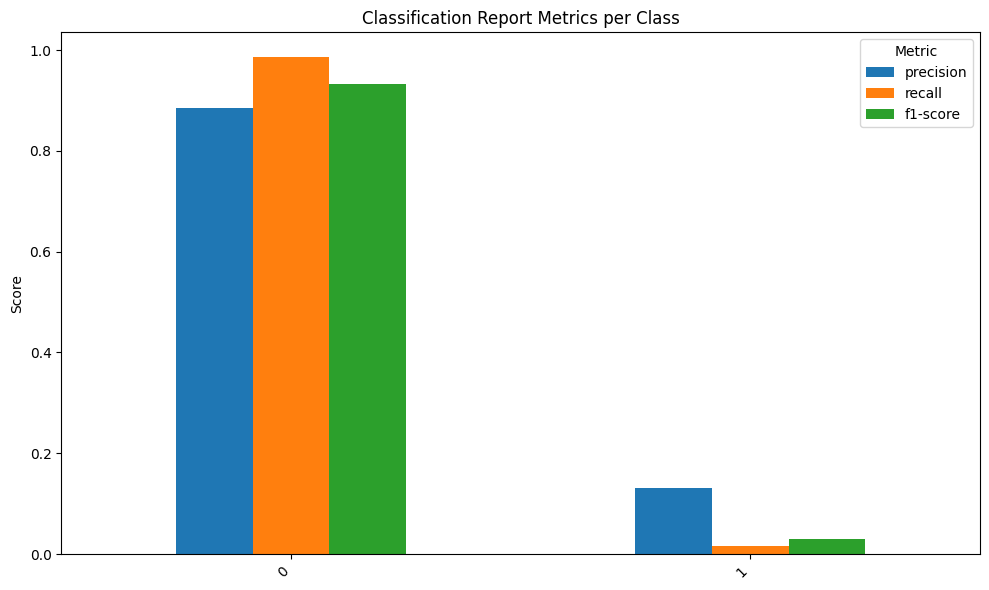

In [27]:
metrics_to_plot = ['precision', 'recall', 'f1-score']
df_plot = stat_1.loc[stat_1.index.difference(['accuracy', 'macro avg', 'weighted avg']), metrics_to_plot]

df_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report Metrics per Class')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [28]:
lr=LinearRegression()
lr.fit(X_train,y_train)
pre_2 = lr.predict(X_test)
print( f"Accuracy Score = {accuracy_score(y_test, pre_2.round())}")
print("Classification Report:")
print(classification_report(y_test, pre_2.round()))
stat_2 = classification_report(y_test, pre_2.round(), output_dict= True)

Accuracy Score = 0.8854
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      8854
           1       0.00      0.00      0.00      1146

    accuracy                           0.89     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.78      0.89      0.83     10000



c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [29]:
stat_2 = pd.DataFrame(stat_2).transpose()

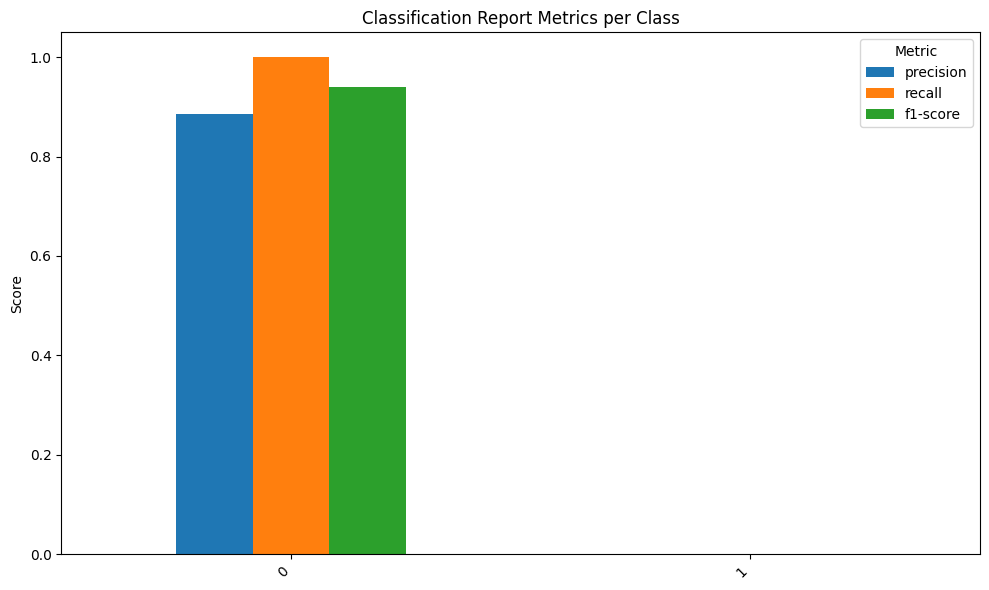

In [30]:
metrics_to_plot = ['precision', 'recall', 'f1-score']
df_plot = stat_2.loc[stat_2.index.difference(['accuracy', 'macro avg', 'weighted avg']), metrics_to_plot]

df_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report Metrics per Class')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()